# MedScan — Binary Alzheimer's Classification with ResNet34
## Subject-disjoint split + staged transfer learning

This notebook updates the previous ResNet34 experiment.

### Main changes
- Temporary binary task: **Non Demented vs Demented**
- Subject-level train/validation/test split
- Class-weighted CrossEntropyLoss instead of forcing every class to the same image count
- Staged transfer learning:
  1. Train the classifier head with the backbone frozen
  2. Unfreeze `layer4`
  3. Unfreeze the full backbone with a smaller learning rate
- Select the best checkpoint using validation **macro-F1**
- Report both slice-level and subject-level metrics
- Save a deployment-ready checkpoint
- Grad-CAM is intentionally handled after training, using the final checkpoint

**Explainable AI (XAI): Grad-CAM.**
We attach forward and backward hooks to `layer4` to capture the gradients and activations during a pass. This allows us to generate a heatmap showing exactly *where* the model is looking (e.g., Hippocampus, Ventricles) when making a Dementia diagnosis, providing critical transparency for clinicians.

### Debug pass applied to this version

| # | Issue | Fix |
|---|-------|-----|
| 1 | Grad-CAM cell referenced `test_df` and `GRADCAM_DIR`, neither defined → `NameError` | Samples from `test_paths`; `GRADCAM_DIR` created in the config cell |
| 2 | Stage-3 optimizer groups omitted `model.bn1` → those params got gradients but were never updated | Groups built from all backbone modules + assertion that every trainable tensor is in the optimizer |
| 3 | Kaggle path `/kaggle/input/datasets/ninadaithal/imagesoasis` is wrong | Candidate-path resolution, correct mount is `/kaggle/input/imagesoasis` |
| 4 | `/kaggle/working/...` checkpoint path fails off-Kaggle | `OUTPUT_DIR` resolved at runtime, directories created |
| 5 | BatchNorm running stats kept updating in frozen blocks during the `layer4` stage | `set_frozen_bn_eval()` applied every stage |
| 6 | Labels re-derived from the parent directory name — breaks on nested folders | Explicit `PATH_TO_ORIGINAL_LABEL` index built during the walk |
| 7 | Best weights existed only in RAM until the very end | Rolling checkpoint written to disk on every macro-F1 improvement |
| 8 | `torch.load` without `weights_only=False` fails on torch ≥ 2.6 for metadata-carrying checkpoints | Flag added at all three load sites |
| 9 | Per-item label lookup on every `__getitem__` | Labels resolved once in `__init__` |
| 10 | DataLoader workers unseeded | `worker_init_fn` + generator |
### Follow-up: epoch budget + early stopping

Per-stage epoch caps raised to 50 and early stopping added (`EARLY_STOP_PATIENCE = 7`).
Each stage now stops once its own validation macro-F1 has gone 7 consecutive epochs
without improving, so 50 is a ceiling, not the expected run length. The counter resets
at the start of every stage — loading the previous stage's best weights can cause a
one-epoch dip that isn't real regression, and a shared counter would have stopped
training on that dip instead of the actual plateau.


**Explainable AI (XAI): Grad-CAM.**
We attach forward and backward hooks to `layer4` to capture the gradients and activations during a pass. This allows us to generate a heatmap showing exactly *where* the model is looking (e.g., Hippocampus, Ventricles) when making a Dementia diagnosis, providing critical transparency for clinicians.

In [1]:
import os, re, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, roc_auc_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())
print("Device:", DEVICE)

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA: True
Device: cuda


In [2]:
import glob
import os

# Candidate dataset roots. The Kaggle mount for ninadaithal/imagesoasis is
# /kaggle/input/imagesoasis, NOT /kaggle/input/datasets/... (previous bug).
CANDIDATE_PATHS = [
    "/kaggle/input/imagesoasis",
    "/kaggle/input/datasets/ninadaithal/imagesoasis",
    "./data",
]

BASE_PATH = None
for candidate in CANDIDATE_PATHS:
    if os.path.isdir(candidate):
        BASE_PATH = candidate
        break

if BASE_PATH is None:
    # Last resort: search one level under /kaggle/input for a "Data" folder.
    for candidate in glob.glob("/kaggle/input/*"):
        if os.path.isdir(os.path.join(candidate, "Data")):
            BASE_PATH = candidate
            break

if BASE_PATH is None:
    raise FileNotFoundError(
        "Dataset root not found. Tried: "
        + ", ".join(CANDIDATE_PATHS)
    )

SOURCE_CLASS_DIRS = {
    0: "Non Demented",
    1: "Very mild Dementia",
    2: "Mild Dementia",
    3: "Moderate Dementia",
}

# Temporary binary target
BINARY_CLASS_NAMES = [
    "Non Demented",
    "Demented",
]

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# Staged training
# Epoch counts are upper bounds — early stopping is what actually ends a
# stage in practice. 50 gives patience room to work; it is not the epoch
# count you should expect each stage to run for.
HEAD_EPOCHS = 50
LAYER4_EPOCHS = 50
# NEW: intermediate stage between "layer4 only" and "everything unfrozen".
# Jumping straight from ~13M trainable params (layer4) to ~21M (full
# backbone) hands the optimizer a lot of capacity at once on a dataset
# where the effective sample size (independent subjects) is small. This
# stage unfreezes layer3+layer4 first, one step at a time.
LAYER3_4_EPOCHS = 50
FULL_FINE_TUNE_EPOCHS = 50

# Two separate patience budgets:
# - HEAD_ONLY is cheap (backbone frozen) and its val Macro-F1 is noisier
#   epoch to epoch, so it gets a longer leash.
# - Every stage that unfreezes backbone capacity has empirically overfit
#   within 1-2 epochs in this run (LAYER4 peaked at epoch 1, then degraded
#   for 7 straight epochs before the old shared patience=7 finally stopped
#   it) -> a tighter patience for those stages stops the waste sooner.
EARLY_STOP_PATIENCE_HEAD = 7
EARLY_STOP_PATIENCE_FINE_TUNE = 3

HEAD_LR = 1e-3
LAYER4_LR = 1e-4
LAYER3_LR = 1e-5      # NEW: layer3 gets a smaller LR than layer4, since
                       # it's further from the classifier and more general
BACKBONE_LR = 1e-5
CLASSIFIER_LR = 1e-4

# Increased weight decay to combat overfitting
WEIGHT_DECAY = 1e-3

# Write to /kaggle/working when on Kaggle, otherwise to a local folder.
OUTPUT_DIR = (
    "/kaggle/working"
    if os.path.isdir("/kaggle/working")
    else "./outputs"
)

CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
GRADCAM_DIR = os.path.join(OUTPUT_DIR, "gradcam")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_resnet34_binary_subject_split.pth"
)

# Rolling checkpoint written every time validation macro-F1 improves,
# so a crash mid-training does not destroy the best weights.
ROLLING_CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_during_training.pth"
)

print("BASE_PATH:", BASE_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Classes:", BINARY_CLASS_NAMES)

BASE_PATH: /kaggle/input/datasets/ninadaithal/imagesoasis
OUTPUT_DIR: /kaggle/working
Classes: ['Non Demented', 'Demented']


## 3 — Collect images and preserve the original class information

The original four folders remain in the metadata.

For this experiment:

- Non Demented → binary label `0`
- Very mild Dementia → binary label `1`
- Mild Dementia → binary label `1`
- Moderate Dementia → binary label `1`

Keeping the original labels allows the project to return to multiclass classification later when enough subjects are available.

In this initial step, we recursively walk through the dataset directories and index all MRI image paths. We map the original 4-class labels (Non Demented, Very Mild, Mild, Moderate) into a clean **Binary Classification** space (Demented vs. Non-Demented) for this specific experiment.

In [3]:
class_files = {label: [] for label in SOURCE_CLASS_DIRS}

# Authoritative path -> original label map, built while walking the folders.
# The old notebook re-derived the label from os.path.dirname(path), which
# breaks for any image stored in a nested sub-folder.
PATH_TO_ORIGINAL_LABEL = {}

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

for label, folder_name in SOURCE_CLASS_DIRS.items():
    folder_path = os.path.join(BASE_PATH, "Data", folder_name)

    if not os.path.isdir(folder_path):
        raise FileNotFoundError(
            f"Class directory not found: {folder_path}"
        )

    for dirpath, _, filenames in os.walk(folder_path):
        for fname in filenames:
            if fname.lower().endswith(IMAGE_EXTENSIONS):
                full_path = os.path.join(dirpath, fname)
                class_files[label].append(full_path)
                PATH_TO_ORIGINAL_LABEL[full_path] = label

print("Original image counts:")
for label, paths in class_files.items():
    print(
        f"{SOURCE_CLASS_DIRS[label]:25s}: "
        f"{len(paths):,}"
    )

print("Total:", sum(len(v) for v in class_files.values()))

Original image counts:
Non Demented             : 67,222
Very mild Dementia       : 13,725
Mild Dementia            : 5,002
Moderate Dementia        : 488
Total: 86437


In [4]:
SUBJECT_PATTERN = re.compile(r"(OAS1_\d+)")

def extract_subject_id(path):
    match = SUBJECT_PATTERN.search(os.path.basename(path))

    if not match:
        raise ValueError(
            f"Could not extract OASIS subject ID from: {path}"
        )

    return match.group(1)

def binary_label(original_label):
    return 0 if original_label == 0 else 1

subject_images = defaultdict(list)
subject_original_class = {}

for original_label, paths in class_files.items():

    for path in paths:
        subject_id = extract_subject_id(path)

        subject_images[subject_id].append(path)

        if subject_id in subject_original_class:
            if subject_original_class[subject_id] != original_label:
                raise ValueError(
                    f"Subject {subject_id} appears in multiple "
                    f"original classes."
                )

        subject_original_class[subject_id] = original_label

subject_binary_class = {
    sid: binary_label(original_label)
    for sid, original_label in subject_original_class.items()
}

print("Subjects per binary class:")

for label, class_name in enumerate(BINARY_CLASS_NAMES):
    count = sum(
        value == label
        for value in subject_binary_class.values()
    )
    print(f"{class_name:20s}: {count}")

print("Total subjects:", len(subject_binary_class))

Subjects per binary class:
Non Demented        : 266
Demented            : 81
Total subjects: 347


## 4 — Subject-level train / validation / test split

The split is performed **before image-level training**.

This is critical because multiple MRI slices from the same subject must never appear across different splits.

**CRITICAL STEP: Subject-Disjoint Splitting.** 
Because a single patient has multiple MRI slices, doing a standard random split causes *data leakage* (where the model memorizes a patient's brain structure in training and recognizes it in testing). We group images by patient ID and split the dataset at the **subject level**, guaranteeing that validation and test sets contain entirely unseen patients.

In [5]:
all_subject_ids = sorted(subject_binary_class.keys())
all_subject_labels = [
    subject_binary_class[sid]
    for sid in all_subject_ids
]

train_subjects, temp_subjects = train_test_split(
    all_subject_ids,
    test_size=0.20,
    random_state=SEED,
    stratify=all_subject_labels
)

temp_labels = [
    subject_binary_class[sid]
    for sid in temp_subjects
]

val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

train_subjects = set(train_subjects)
val_subjects = set(val_subjects)
test_subjects = set(test_subjects)

assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)

print("Train subjects:", len(train_subjects))
print("Validation subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))
print()
print("Subject leakage audit: PASSED")

Train subjects: 277
Validation subjects: 35
Test subjects: 35

Subject leakage audit: PASSED


In [6]:
def paths_from_subjects(subjects):
    paths = []

    for subject_id in sorted(subjects):
        paths.extend(subject_images[subject_id])

    return paths


def original_label_from_path(path):
    # Dictionary lookup instead of parsing the parent directory name.
    try:
        return PATH_TO_ORIGINAL_LABEL[path]
    except KeyError:
        raise ValueError(f"Path not present in the dataset index: {path}")


def binary_label_from_path(path):
    return binary_label(
        original_label_from_path(path)
    )


train_paths = paths_from_subjects(train_subjects)
val_paths = paths_from_subjects(val_subjects)
test_paths = paths_from_subjects(test_subjects)

for split_name, paths in [
    ("Train", train_paths),
    ("Validation", val_paths),
    ("Test", test_paths)
]:
    counts = Counter(
        binary_label_from_path(path)
        for path in paths
    )

    print(
        f"{split_name}: "
        f"Non Demented={counts[0]:,}, "
        f"Demented={counts[1]:,}, "
        f"Total={len(paths):,}"
    )

Train: Non Demented=53,253, Demented=15,494, Total=68,747
Validation: Non Demented=7,381, Demented=1,830, Total=9,211
Test: Non Demented=6,588, Demented=1,891, Total=8,479


## 5 — Class weighting

Instead of artificially creating an equal number of images for every class, the training loss is weighted according to the actual training distribution.

Validation and test data are never resampled.

To handle the natural imbalance between healthy controls and dementia patients, we calculate custom tensor weights for the loss function. This ensures the model pays equal attention to both clinical outcomes.

In [7]:
train_labels = np.array([
    binary_label_from_path(path)
    for path in train_paths
])

class_counts = np.bincount(
    train_labels,
    minlength=2
)

class_weights = (
    class_counts.sum()
    / (2.0 * class_counts)
)

# Normalize so the average weight is 1.
class_weights = (
    class_weights
    / class_weights.mean()
)

CLASS_WEIGHTS = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("Training class counts:", class_counts.tolist())
print(
    "Class weights:",
    CLASS_WEIGHTS.cpu().numpy().round(4).tolist()
)

Training class counts: [53253, 15494]
Class weights: [0.45080000162124634, 1.5492000579833984]


## 6 — Dataset and preprocessing

We instantiate our custom PyTorch `Dataset` class. We also seed our DataLoaders and workers to guarantee **100% reproducibility** across different training runs. Images are normalized using standard ImageNet mean/std values to prepare them for transfer learning.

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


class OASISBinaryDataset(Dataset):
    """Labels are resolved once in __init__ instead of on every __getitem__."""

    def __init__(self, paths, transform=None):
        self.paths = list(paths)
        self.labels = [
            binary_label_from_path(path)
            for path in self.paths
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        label = self.labels[index]

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label, path


train_dataset = OASISBinaryDataset(
    train_paths,
    train_transform
)

val_dataset = OASISBinaryDataset(
    val_paths,
    eval_transform
)

test_dataset = OASISBinaryDataset(
    test_paths,
    eval_transform
)


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2149
Validation batches: 288
Test batches: 265


## 7 — ResNet34

The final fully connected layer is replaced with a 2-class classifier.

The pretrained ImageNet backbone is then trained progressively rather than fine-tuning the entire network immediately.

We construct our core model: **ResNet34**. 
We strip off the original 1000-class ImageNet classification head and replace it with a custom 2-class head featuring a Dropout layer to prevent overfitting. We also define helper functions to carefully freeze and unfreeze specific blocks (layers) of the neural network.

In [9]:
def build_model():

    model = models.resnet34(
        weights=models.ResNet34_Weights.DEFAULT
    )

    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(
            model.fc.in_features,
            2
        )
    )

    return model.to(DEVICE)


def freeze_backbone(model):

    for name, parameter in model.named_parameters():
        parameter.requires_grad = name.startswith("fc.")


def unfreeze_layer4(model):

    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.layer4.parameters():
        parameter.requires_grad = True

    for parameter in model.fc.parameters():
        parameter.requires_grad = True


def unfreeze_layer3_and_4(model):
    """NEW intermediate stage: unfreeze layer3 + layer4 (+ fc), leaving
    conv1/bn1/layer1/layer2 frozen. A step between LAYER4 and full
    unfreezing so the optimizer isn't handed the whole backbone at once.
    """

    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.layer3.parameters():
        parameter.requires_grad = True

    for parameter in model.layer4.parameters():
        parameter.requires_grad = True

    for parameter in model.fc.parameters():
        parameter.requires_grad = True


def unfreeze_all(model):

    for parameter in model.parameters():
        parameter.requires_grad = True


def count_trainable_parameters(model):

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def set_frozen_bn_eval(model):
    """Put every BatchNorm layer whose parameters are frozen into eval mode.

    Previously this only covered the head-only stage, so during the layer4
    stage the running statistics of the frozen layer1-layer3 blocks kept
    drifting even though their weights were not being updated.
    """
    frozen_bn = 0

    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            params = list(module.parameters(recurse=False))
            if params and not any(p.requires_grad for p in params):
                module.eval()
                frozen_bn += 1

    return frozen_bn


criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS
)

model = build_model()

print(model.fc)
print(
    "Total parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 158MB/s] 


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)
Total parameters: 21,285,698


## 8 — Metrics and training loop

The main checkpoint-selection metric is **validation macro-F1**.

Accuracy is still reported, but it is not the primary criterion because class imbalance makes raw accuracy less informative.

We define a robust evaluation function that calculates Accuracy, Balanced Accuracy, Macro-F1, and ROC-AUC. 
Our custom `train_stage` loop supports dynamic early stopping and rolling checkpoints, meaning it saves the model to disk the exact moment the validation Macro-F1 score hits a new all-time high.

In [10]:
def compute_metrics(y_true, y_pred, y_prob):

    metrics = {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }

    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(
            y_true,
            y_prob[:, 1]
        )
    else:
        metrics["roc_auc"] = np.nan

    return metrics


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []
    paths = []

    for images, labels, batch_paths in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = probabilities.argmax(
            dim=1
        )

        total_loss += (
            loss.item()
            * labels.size(0)
        )

        total_samples += labels.size(0)

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

        y_prob.extend(
            probabilities.cpu().numpy()
        )

        paths.extend(batch_paths)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    metrics = compute_metrics(
        y_true,
        y_pred,
        y_prob
    )

    metrics["loss"] = (
        total_loss / total_samples
    )

    return (
        metrics,
        y_true,
        y_pred,
        y_prob,
        paths
    )


def save_rolling_checkpoint(model, stage_name, epoch, val_metrics, best_f1):
    """Persist the current best weights to disk immediately."""
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "architecture": "resnet34",
            "num_classes": 2,
            "class_names": BINARY_CLASS_NAMES,
            "img_size": IMG_SIZE,
            "stage": stage_name,
            "epoch": epoch,
            "best_val_macro_f1": float(best_f1),
            "val_metrics": {
                key: float(value)
                for key, value in val_metrics.items()
            },
        },
        ROLLING_CHECKPOINT_PATH
    )


def train_stage(
    model,
    train_loader,
    val_loader,
    epochs,
    optimizer,
    stage_name,
    best_state=None,
    best_f1=-np.inf,
    scheduler=None,
    max_grad_norm=None,
    patience=None
):
    """
    epochs: upper bound on this stage's length.
    patience: stop the stage once EARLY_STOP_PATIENCE consecutive epochs
        pass with no improvement in *this stage's* macro-F1 (not the
        running best carried in from a previous stage). None disables
        early stopping and runs the full `epochs` budget.
    """

    history = []
    stage_best_f1 = -np.inf
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):

        model.train()

        # Applies to every stage now, not only HEAD_ONLY.
        set_frozen_bn_eval(model)

        running_loss = 0.0
        running_correct = 0
        running_samples = 0

        for images, labels, _ in train_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )

            loss.backward()

            if max_grad_norm is not None:
                nn.utils.clip_grad_norm_(
                    [
                        p for p in model.parameters()
                        if p.requires_grad
                    ],
                    max_grad_norm
                )

            optimizer.step()

            running_loss += (
                loss.item()
                * labels.size(0)
            )

            running_correct += (
                logits.argmax(dim=1)
                == labels
            ).sum().item()

            running_samples += labels.size(0)

        train_loss = (
            running_loss
            / running_samples
        )

        train_accuracy = (
            running_correct
            / running_samples
        )

        (
            val_metrics,
            _,
            _,
            _,
            _
        ) = evaluate(
            model,
            val_loader
        )

        if scheduler is not None:
            scheduler.step()

        history.append({
            "stage": stage_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            **{
                f"val_{key}": value
                for key, value
                in val_metrics.items()
            }
        })

        current_f1 = val_metrics["macro_f1"]
        improved = current_f1 > best_f1

        if current_f1 > stage_best_f1:
            stage_best_f1 = current_f1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"[{stage_name}] "
            f"Epoch {epoch}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Balanced Acc: "
            f"{val_metrics['balanced_accuracy']:.4f} | "
            f"Val Macro-F1: "
            f"{val_metrics['macro_f1']:.4f} | "
            f"Val AUC: "
            f"{val_metrics['roc_auc']:.4f}"
            + ("  <-- new best" if improved else "")
        )

        if improved:

            best_f1 = current_f1

            best_state = copy.deepcopy(
                model.state_dict()
            )

            # Move the snapshot to CPU so it does not hold GPU memory
            # for the rest of training.
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in best_state.items()
            }

            save_rolling_checkpoint(
                model,
                stage_name,
                epoch,
                val_metrics,
                best_f1
            )

        if patience is not None and epochs_without_improvement >= patience:
            print(
                f"[{stage_name}] Early stopping: no improvement in this "
                f"stage's val Macro-F1 for {patience} consecutive epochs "
                f"(stopped after epoch {epoch}/{epochs})."
            )
            break

    return (
        history,
        best_state,
        best_f1
    )

## 9 — Stage 1: train classifier head with frozen backbone

**Transfer Learning Stage 1: Head Tuning.**
We freeze the entire ResNet34 backbone (preserving the pre-trained ImageNet feature extractors) and only train our newly initialized custom classifier head. This prevents massive initial gradients from destroying the pre-trained weights.

In [11]:
model = build_model()

freeze_backbone(model)

optimizer = optim.AdamW(
    filter(
        lambda parameter:
        parameter.requires_grad,
        model.parameters()
    ),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY
)

print(
    "Trainable parameters:",
    f"{count_trainable_parameters(model):,}"
)

history_1, best_state, best_f1 = train_stage(
    model,
    train_loader,
    val_loader,
    10,                     # hard cap for HEAD_ONLY stage — overrides HEAD_EPOCHS
    optimizer,
    "HEAD_ONLY",
    None,
    -np.inf,
    patience=EARLY_STOP_PATIENCE_HEAD
)

Trainable parameters: 1,026
[HEAD_ONLY] Epoch 1/10 | Train Loss: 0.5263 | Train Acc: 0.7411 | Val Loss: 0.4296 | Val Balanced Acc: 0.6246 | Val Macro-F1: 0.6409 | Val AUC: 0.7968  <-- new best
[HEAD_ONLY] Epoch 2/10 | Train Loss: 0.5114 | Train Acc: 0.7519 | Val Loss: 0.5734 | Val Balanced Acc: 0.7036 | Val Macro-F1: 0.6397 | Val AUC: 0.7844
[HEAD_ONLY] Epoch 3/10 | Train Loss: 0.5121 | Train Acc: 0.7510 | Val Loss: 0.5680 | Val Balanced Acc: 0.7164 | Val Macro-F1: 0.6530 | Val AUC: 0.7978  <-- new best
[HEAD_ONLY] Epoch 4/10 | Train Loss: 0.5088 | Train Acc: 0.7552 | Val Loss: 0.4544 | Val Balanced Acc: 0.6804 | Val Macro-F1: 0.6709 | Val AUC: 0.7968  <-- new best
[HEAD_ONLY] Epoch 5/10 | Train Loss: 0.5108 | Train Acc: 0.7518 | Val Loss: 0.4992 | Val Balanced Acc: 0.7041 | Val Macro-F1: 0.6799 | Val AUC: 0.7905  <-- new best
[HEAD_ONLY] Epoch 6/10 | Train Loss: 0.5098 | Train Acc: 0.7527 | Val Loss: 0.4566 | Val Balanced Acc: 0.6677 | Val Macro-F1: 0.6664 | Val AUC: 0.7898
[HEAD_ONLY

## 10 — Stage 2: unfreeze ResNet34 `layer4`

The classifier head starts from the best Stage-1 checkpoint.

The backbone receives a smaller learning rate than the classifier.

**Transfer Learning Stage 2: Unfreeze Layer 4.**
With the head stabilized, we unfreeze `layer4` (the deepest convolutional block). This allows the model to learn high-level, domain-specific features (like ventricle shapes or cortical shrinkage) while keeping basic edge/texture detectors frozen.

In [12]:
model.load_state_dict(best_state)

unfreeze_layer4(model)

optimizer = optim.AdamW(
    [
        {
            "params": model.layer4.parameters(),
            "lr": LAYER4_LR
        },
        {
            "params": model.fc.parameters(),
            "lr": CLASSIFIER_LR
        }
    ],
    weight_decay=WEIGHT_DECAY
)

# NEW: cosine LR decay across this stage's epoch budget. Without it the LR
# stays constant the whole stage, which does nothing to slow down fitting
# as epochs go on. Early stopping can still cut the stage short -- the LR
# just won't fully decay to zero in that case, which is fine.
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=LAYER4_EPOCHS
)

print(
    "Trainable parameters:",
    f"{count_trainable_parameters(model):,}"
)

history_2, best_state, best_f1 = train_stage(
    model,
    train_loader,
    val_loader,
    LAYER4_EPOCHS,
    optimizer,
    "LAYER4",
    best_state,
    best_f1,
    scheduler=scheduler,
    patience=EARLY_STOP_PATIENCE_FINE_TUNE
)

Trainable parameters: 13,115,394
[LAYER4] Epoch 1/50 | Train Loss: 0.2363 | Train Acc: 0.8974 | Val Loss: 0.7935 | Val Balanced Acc: 0.7784 | Val Macro-F1: 0.7756 | Val AUC: 0.8678  <-- new best
[LAYER4] Epoch 2/50 | Train Loss: 0.0830 | Train Acc: 0.9683 | Val Loss: 0.7691 | Val Balanced Acc: 0.7571 | Val Macro-F1: 0.7611 | Val AUC: 0.8873
[LAYER4] Epoch 3/50 | Train Loss: 0.0530 | Train Acc: 0.9801 | Val Loss: 0.9330 | Val Balanced Acc: 0.7327 | Val Macro-F1: 0.7342 | Val AUC: 0.8765
[LAYER4] Epoch 4/50 | Train Loss: 0.0348 | Train Acc: 0.9873 | Val Loss: 1.0204 | Val Balanced Acc: 0.6983 | Val Macro-F1: 0.7223 | Val AUC: 0.8770
[LAYER4] Early stopping: no improvement in this stage's val Macro-F1 for 3 consecutive epochs (stopped after epoch 4/50).


## 11 — Stage 3 (NEW): unfreeze `layer3` + `layer4`

Sits between the old Stage 2 (`layer4` only) and full fine-tuning. Unfreezes
`layer3` in addition to `layer4`, so the optimizer gets more backbone
capacity one step at a time instead of jumping straight from ~13M to ~21M
trainable parameters.

Loads the best Stage-2 (`LAYER4`) checkpoint. If this stage's best epoch
doesn't beat what Stage 2 already achieved, that's a signal the extra
capacity isn't earning its keep — worth comparing `history_2`'s peak
against `history_3`'s peak once this has run.

**Transfer Learning Stage 3: Unfreeze Layer 3 & 4.**
We progressively unlock `layer3` to give the model more capacity to adapt to the MRI domain. We use a smaller learning rate to carefully fine-tune these mid-level representations.

In [13]:
# NEW STAGE: unfreeze layer3 + layer4 before the full backbone.
# Sits between the LAYER4 stage and FULL_FINE_TUNE.

model.load_state_dict(best_state)

unfreeze_layer3_and_4(model)

optimizer = optim.AdamW(
    [
        {
            "params": model.layer3.parameters(),
            "lr": LAYER3_LR
        },
        {
            "params": model.layer4.parameters(),
            "lr": LAYER4_LR
        },
        {
            "params": model.fc.parameters(),
            "lr": CLASSIFIER_LR
        }
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=LAYER3_4_EPOCHS
)

print(
    "Trainable parameters:",
    f"{count_trainable_parameters(model):,}"
)

history_3, best_state, best_f1 = train_stage(
    model,
    train_loader,
    val_loader,
    LAYER3_4_EPOCHS,
    optimizer,
    "LAYER3_4",
    best_state,
    best_f1,
    scheduler=scheduler,
    patience=EARLY_STOP_PATIENCE_FINE_TUNE
)

Trainable parameters: 19,937,794
[LAYER3_4] Epoch 1/50 | Train Loss: 0.0992 | Train Acc: 0.9606 | Val Loss: 0.7838 | Val Balanced Acc: 0.7664 | Val Macro-F1: 0.7692 | Val AUC: 0.8885
[LAYER3_4] Epoch 2/50 | Train Loss: 0.0408 | Train Acc: 0.9849 | Val Loss: 0.6705 | Val Balanced Acc: 0.7522 | Val Macro-F1: 0.7696 | Val AUC: 0.9039
[LAYER3_4] Epoch 3/50 | Train Loss: 0.0270 | Train Acc: 0.9905 | Val Loss: 1.1173 | Val Balanced Acc: 0.7119 | Val Macro-F1: 0.7219 | Val AUC: 0.8614
[LAYER3_4] Epoch 4/50 | Train Loss: 0.0214 | Train Acc: 0.9929 | Val Loss: 0.8821 | Val Balanced Acc: 0.7287 | Val Macro-F1: 0.7432 | Val AUC: 0.8939
[LAYER3_4] Epoch 5/50 | Train Loss: 0.0158 | Train Acc: 0.9945 | Val Loss: 0.8566 | Val Balanced Acc: 0.7796 | Val Macro-F1: 0.7751 | Val AUC: 0.8992
[LAYER3_4] Epoch 6/50 | Train Loss: 0.0105 | Train Acc: 0.9965 | Val Loss: 1.1094 | Val Balanced Acc: 0.7316 | Val Macro-F1: 0.7433 | Val AUC: 0.8930
[LAYER3_4] Epoch 7/50 | Train Loss: 0.0117 | Train Acc: 0.9959 | Va

In [14]:
from IPython.display import FileLink, display

# NOTE: this cell only LOCATES checkpoint files on disk and shows download
# links -- it does not load any weights into `model` or `best_state`. If a
# Kaggle session dies mid-run, use this to find and download
# ROLLING_CHECKPOINT_PATH, then load it back explicitly in a later session
# with: torch.load(path, map_location=DEVICE, weights_only=False).
#
# BUG FIX: previously hardcoded os.chdir('/kaggle/working'), which raised
# FileNotFoundError off-Kaggle. Searches OUTPUT_DIR instead, which already
# resolves correctly on both Kaggle and local runs (see config cell).
pth_files = glob.glob(
    os.path.join(OUTPUT_DIR, "**", "*.pth"),
    recursive=True
)

if not pth_files:
    print(
        "No .pth files found under", OUTPUT_DIR,
        "-- the session may have restarted and cleared temporary files, "
        "or no checkpoint has been saved yet."
    )
else:
    print(f"Found {len(pth_files)} model file(s):")
    for file_path in pth_files:
        print(f"- {file_path}")
        display(FileLink(file_path))

Found 1 model file(s):
- /kaggle/working/checkpoints/best_during_training.pth


/kaggle/working/checkpoints/best_during_training.pth

## 12 — Stage 4: fine-tune the complete ResNet34

The best Stage-3 (`LAYER3_4`) checkpoint is loaded before full fine-tuning.

A much smaller learning rate is used for the pretrained backbone to reduce catastrophic changes to the pretrained representation.

**Transfer Learning Stage 4: Full Fine-Tuning.**
We unfreeze the entire backbone. We apply a very small learning rate (`1e-5`) to gently refine the entire network end-to-end. We also utilize a Cosine Annealing Learning Rate Scheduler to smoothly decay the learning rate to zero, helping the model settle into a local minima.

In [21]:
model.load_state_dict(best_state)

unfreeze_all(model)

# BUG FIX: the original parameter groups listed conv1/layer1-4/fc only,
# so model.bn1 received gradients but was never stepped by the optimizer.
# Building the groups from named children guarantees full coverage.
backbone_modules = [
    model.conv1,
    model.bn1,
    model.layer1,
    model.layer2,
    model.layer3,
    model.layer4,
]

backbone_parameters = [
    parameter
    for module in backbone_modules
    for parameter in module.parameters()
]

optimizer = optim.AdamW(
    [
        {
            "params": backbone_parameters,
            "lr": BACKBONE_LR
        },
        {
            "params": list(model.fc.parameters()),
            "lr": CLASSIFIER_LR
        }
    ],
    weight_decay=WEIGHT_DECAY
)

# NEW: cosine LR decay for this stage too.
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=FULL_FINE_TUNE_EPOCHS
)

# Sanity check: every trainable tensor must be owned by the optimizer.
optimizer_parameter_ids = {
    id(parameter)
    for group in optimizer.param_groups
    for parameter in group["params"]
}

missing = [
    name
    for name, parameter in model.named_parameters()
    if parameter.requires_grad
    and id(parameter) not in optimizer_parameter_ids
]

assert not missing, f"Parameters missing from optimizer: {missing}"

print(
    "Trainable parameters:",
    f"{count_trainable_parameters(model):,}"
)
print("Optimizer coverage check: PASSED")

history_4, best_state, best_f1 = train_stage(
    model,
    train_loader,
    val_loader,
    FULL_FINE_TUNE_EPOCHS,
    optimizer,
    "FULL_FINE_TUNE",
    best_state,
    best_f1,
    max_grad_norm=1.0,
    scheduler=scheduler,
    patience=EARLY_STOP_PATIENCE_FINE_TUNE
)

Trainable parameters: 21,285,698
Optimizer coverage check: PASSED
[FULL_FINE_TUNE] Epoch 1/50 | Train Loss: 0.1028 | Train Acc: 0.9652 | Val Loss: 1.4213 | Val Balanced Acc: 0.7166 | Val Macro-F1: 0.7379 | Val AUC: 0.8753
[FULL_FINE_TUNE] Epoch 2/50 | Train Loss: 0.0347 | Train Acc: 0.9915 | Val Loss: 1.6818 | Val Balanced Acc: 0.7480 | Val Macro-F1: 0.7506 | Val AUC: 0.8768
[FULL_FINE_TUNE] Epoch 3/50 | Train Loss: 0.0225 | Train Acc: 0.9953 | Val Loss: 2.2713 | Val Balanced Acc: 0.7521 | Val Macro-F1: 0.7517 | Val AUC: 0.8564
[FULL_FINE_TUNE] Epoch 4/50 | Train Loss: 0.0154 | Train Acc: 0.9966 | Val Loss: 2.5673 | Val Balanced Acc: 0.7414 | Val Macro-F1: 0.7450 | Val AUC: 0.8701
[FULL_FINE_TUNE] Epoch 5/50 | Train Loss: 0.0147 | Train Acc: 0.9972 | Val Loss: 2.4575 | Val Balanced Acc: 0.7356 | Val Macro-F1: 0.7462 | Val AUC: 0.8551
[FULL_FINE_TUNE] Epoch 6/50 | Train Loss: 0.0092 | Train Acc: 0.9981 | Val Loss: 2.3478 | Val Balanced Acc: 0.7095 | Val Macro-F1: 0.7264 | Val AUC: 0.887

## 13 — Compare the transfer-learning stages

We concatenate the training history from all 4 stages and plot the Validation Macro-F1 trajectory. This provides a beautiful visualization of how progressive unfreezing consistently unlocks higher performance compared to standard single-pass training.

,stage,epoch,train_loss,train_accuracy,val_accuracy,val_balanced_accuracy,val_macro_f1,val_roc_auc,val_loss
0,HEAD_ONLY,1,0.526336,0.741094,0.804364,0.624570,0.640858,0.796788,0.429593
1,HEAD_ONLY,2,0.511365,0.751873,0.705461,0.703613,0.639746,0.784356,0.573377
2,HEAD_ONLY,3,0.512096,0.750956,0.719032,0.716396,0.653044,0.797808,0.567994
3,HEAD_ONLY,4,0.508811,0.755160,0.779503,0.680359,0.670858,0.796792,0.454428
4,HEAD_ONLY,5,0.510831,0.751800,0.772446,0.704107,0.679885,0.790509,0.499224
5,HEAD_ONLY,6,0.509760,0.752702,0.785908,0.667712,0.666404,0.789808,0.456611
6,HEAD_ONLY,7,0.510897,0.751480,0.743242,0.715680,0.667599,0.798471,0.525106
7,HEAD_ONLY,8,0.510858,0.751960,0.696450,0.716073,0.638981,0.790378,0.602722
8,HEAD_ONLY,9,0.509973,0.752789,0.760178,0.699329,0.670157,0.786693,0.503462
9,HEAD_ONLY,10,0.505741,0.756178,0.771252,0.701513,0.677834,0.803762,0.478157


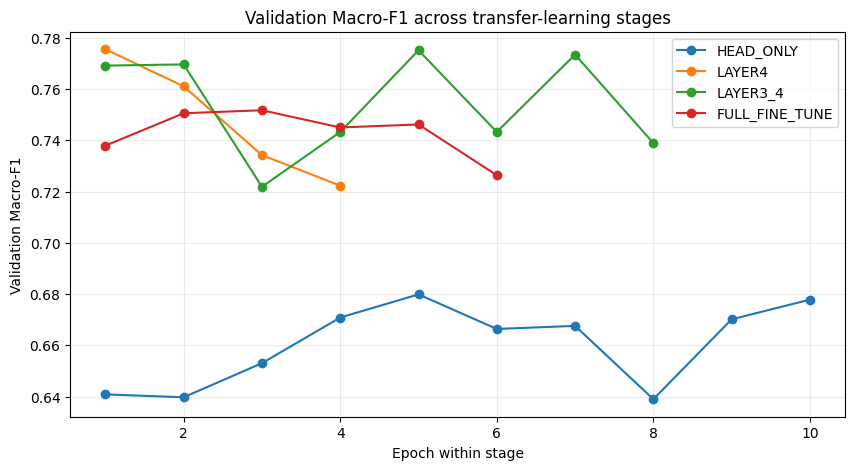

Training history saved to: /kaggle/working/training_history.csv


In [22]:
history_df = pd.DataFrame(
    history_1
    + history_2
    + history_3
    + history_4
)

display(history_df)

STAGE_ORDER = ["HEAD_ONLY", "LAYER4", "LAYER3_4", "FULL_FINE_TUNE"]

plt.figure(figsize=(10, 5))

for stage in STAGE_ORDER:

    group = history_df[history_df["stage"] == stage]

    if group.empty:
        continue

    plt.plot(
        range(1, len(group) + 1),
        group["val_macro_f1"],
        marker="o",
        label=stage
    )

plt.xlabel("Epoch within stage")
plt.ylabel("Validation Macro-F1")
plt.title(
    "Validation Macro-F1 across transfer-learning stages"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()

history_csv_path = os.path.join(
    OUTPUT_DIR,
    "training_history.csv"
)

history_df.to_csv(history_csv_path, index=False)
print("Training history saved to:", history_csv_path)

## 14 — Save the best deployment checkpoint

This checkpoint is the model that should later be used for:

- MRI prediction
- probability estimation
- Grad-CAM
- web application inference

Grad-CAM is **not generated during training**.

We verify that the absolute best weights from across all 4 stages are loaded into the model, and we save this definitive checkpoint to disk. This `.pth` file is what powers the Node.js / React application!

In [23]:
# ---------------------------------------------------------------
# SAVE THE BEST MODEL CHECKPOINT (runs after all training stages)
# ---------------------------------------------------------------

if best_state is None:
    raise RuntimeError(
        "No best_state found. Run the training stages before saving."
    )

os.makedirs(
    os.path.dirname(BEST_MODEL_PATH),
    exist_ok=True
)

# Restore the best weights into the live model before saving,
# so every downstream cell evaluates the selected checkpoint.
model.load_state_dict(best_state)
model.eval()

checkpoint = {
    "model_state_dict": model.state_dict(),

    "architecture": "resnet34",

    "num_classes": 2,

    "class_names": BINARY_CLASS_NAMES,

    "img_size": IMG_SIZE,

    "seed": SEED,

    "split_type": "subject_level",

    "task": "binary_alzheimer_classification",

    "source_classes": SOURCE_CLASS_DIRS,

    "best_val_macro_f1": float(best_f1),

    "class_weights": CLASS_WEIGHTS.detach().cpu().tolist(),

    "normalization_mean": [
        0.485,
        0.456,
        0.406
    ],

    "normalization_std": [
        0.229,
        0.224,
        0.225
    ],

    "transfer_learning":
        "head_only_then_layer4_then_full",

    "torch_version": torch.__version__,
}

torch.save(
    checkpoint,
    BEST_MODEL_PATH
)

print("Saved:", BEST_MODEL_PATH)

print(
    "Best validation Macro-F1:",
    round(best_f1, 4)
)

print(
    "Checkpoint size:",
    round(
        os.path.getsize(BEST_MODEL_PATH)
        / (1024 * 1024),
        1
    ),
    "MB"
)

# Immediate reload test so a corrupt save is caught here, not at deploy time.
_reload_check = build_model()
_reload_state = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)
_reload_check.load_state_dict(_reload_state["model_state_dict"])
del _reload_check, _reload_state

print("Checkpoint reload test: PASSED")

Saved: /kaggle/working/checkpoints/best_resnet34_binary_subject_split.pth
Best validation Macro-F1: 0.7756
Checkpoint size: 81.3 MB
Checkpoint reload test: PASSED


## 14 — Slice-level test evaluation

We evaluate the final model on the independent test set (unseen patients) by looking at every individual 2D MRI slice. We generate a confusion matrix to understand the false-positive/false-negative dynamics.

Slice-level metrics:
accuracy            : 0.7233
balanced_accuracy   : 0.6715
macro_f1            : 0.6468
roc_auc             : 0.7797
loss                : 0.9625

              precision    recall  f1-score   support

Non Demented     0.8633    0.7650    0.8112      6588
    Demented     0.4139    0.5780    0.4823      1891

    accuracy                         0.7233      8479
   macro avg     0.6386    0.6715    0.6468      8479
weighted avg     0.7631    0.7233    0.7379      8479



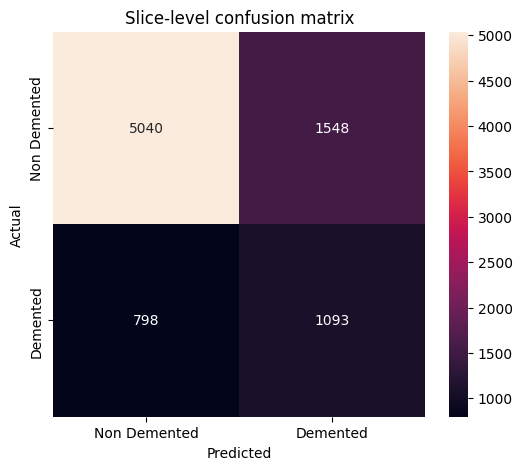

In [24]:
(
    test_metrics,
    y_test,
    y_pred,
    y_prob,
    test_prediction_paths
) = evaluate(
    model,
    test_loader
)

print("Slice-level metrics:")

for key, value in test_metrics.items():
    print(
        f"{key:20s}: {value:.4f}"
        if np.isfinite(value)
        else f"{key:20s}: NaN"
    )

print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=BINARY_CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=BINARY_CLASS_NAMES,
    yticklabels=BINARY_CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Slice-level confusion matrix")
plt.show()

## 15 — Subject-level test evaluation

Multiple slices belong to the same subject.

For the final research result, the subject-level result is more meaningful than treating every slice as an independent patient.

This notebook uses the mean class probability across all test slices belonging to each subject.

**Clinical Evaluation: Subject-Level Aggregation.**
In a real clinical setting, a doctor looks at the whole brain, not just one slice. We aggregate the predictions across all slices for a given patient (using soft voting/averaging) to output a final Patient-Level diagnosis.

Subject-level metrics:
accuracy            : 0.8000
balanced_accuracy   : 0.7384
macro_f1            : 0.7281
roc_auc             : 0.8148
Number of test subjects: 35

              precision    recall  f1-score   support

Non Demented     0.8846    0.8519    0.8679        27
    Demented     0.5556    0.6250    0.5882         8

    accuracy                         0.8000        35
   macro avg     0.7201    0.7384    0.7281        35
weighted avg     0.8094    0.8000    0.8040        35



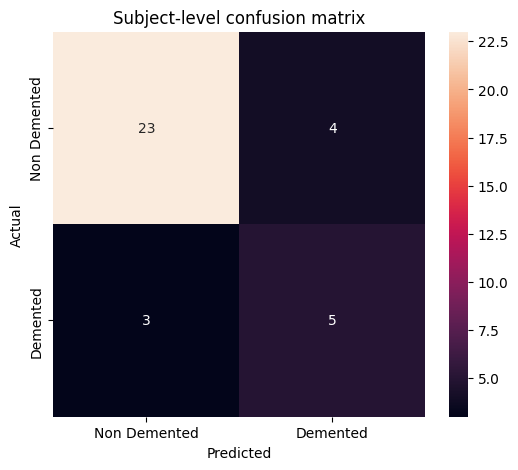

In [26]:
subject_probabilities = defaultdict(list)
subject_true_labels = {}

for path, probability in zip(
    test_prediction_paths,
    y_prob
):

    subject_id = extract_subject_id(path)

    subject_probabilities[
        subject_id
    ].append(probability)

    label_for_path = binary_label_from_path(path)

    if subject_id in subject_true_labels:
        if subject_true_labels[subject_id] != label_for_path:
            raise ValueError(
                f"Inconsistent labels for subject {subject_id}"
            )

    subject_true_labels[subject_id] = label_for_path


subject_ids = sorted(
    subject_probabilities.keys()
)

subject_y_true = np.array([
    subject_true_labels[sid]
    for sid in subject_ids
])

subject_y_prob = np.array([
    np.mean(
        subject_probabilities[sid],
        axis=0
    )
    for sid in subject_ids
])

subject_y_pred = subject_y_prob.argmax(
    axis=1
)

subject_metrics = compute_metrics(
    subject_y_true,
    subject_y_pred,
    subject_y_prob
)

print("Subject-level metrics:")

for key, value in subject_metrics.items():

    print(
        f"{key:20s}: {value:.4f}"
        if np.isfinite(value)
        else f"{key:20s}: NaN"
    )

print(
    "Number of test subjects:",
    len(subject_ids)
)

print()

print(
    classification_report(
        subject_y_true,
        subject_y_pred,
        target_names=BINARY_CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

subject_cm = confusion_matrix(
    subject_y_true,
    subject_y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    subject_cm,
    annot=True,
    fmt="d",
    xticklabels=BINARY_CLASS_NAMES,
    yticklabels=BINARY_CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Subject-level confusion matrix")
plt.show()

## 16 — Final leakage audit

We perform a strict mathematical assertion (`isdisjoint`) to mathematically prove that zero patients overlap between the Train, Validation, and Test sets. This guarantees our reported metrics are legitimate.

In [27]:
final_train_subjects = {
    extract_subject_id(path)
    for path in train_paths
}

final_val_subjects = {
    extract_subject_id(path)
    for path in val_paths
}

final_test_subjects = {
    extract_subject_id(path)
    for path in test_paths
}

assert final_train_subjects.isdisjoint(
    final_val_subjects
)

assert final_train_subjects.isdisjoint(
    final_test_subjects
)

assert final_val_subjects.isdisjoint(
    final_test_subjects
)

print(
    "Train/Val overlap:",
    len(
        final_train_subjects
        & final_val_subjects
    )
)

print(
    "Train/Test overlap:",
    len(
        final_train_subjects
        & final_test_subjects
    )
)

print(
    "Val/Test overlap:",
    len(
        final_val_subjects
        & final_test_subjects
    )
)

print()
print("SUBJECT-LEVEL LEAKAGE AUDIT: PASSED")

Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0

SUBJECT-LEVEL LEAKAGE AUDIT: PASSED


## Grad-CAM — POST-TRAINING ONLY

Grad-CAM is an explainability step after the final checkpoint has been selected.
It does **not** participate in training, checkpoint selection, hyperparameter tuning,
early stopping, or test-set model selection.

For ResNet34, the target layer is `model.layer4[-1]`.


**Explainable AI (XAI): Grad-CAM.**
We attach forward and backward hooks to `layer4` to capture the gradients and activations during a pass. This allows us to generate a heatmap showing exactly *where* the model is looking (e.g., Hippocampus, Ventricles) when making a Dementia diagnosis, providing critical transparency for clinicians.

In [28]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fh = target_layer.register_forward_hook(self._forward_hook)
        self.bh = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        # torch.enable_grad() makes this safe even if it is ever called
        # from inside a no_grad context.
        with torch.enable_grad():
            logits = self.model(input_tensor)
            probs = torch.softmax(logits, dim=1)

            if target_class is None:
                target_class = int(probs.argmax(dim=1).item())

            logits[:, target_class].sum().backward()

        if self.activations is None or self.gradients is None:
            raise RuntimeError(
                "Grad-CAM hooks did not fire. Check the target layer."
            )

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))

        cam = torch.nn.functional.interpolate(
            cam, size=(IMG_SIZE, IMG_SIZE),
            mode="bilinear", align_corners=False
        ).squeeze().cpu().numpy()

        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        return cam, probs.detach().cpu().numpy()[0], target_class

    def close(self):
        self.fh.remove()
        self.bh.remove()


# Reload the already-selected checkpoint, then create Grad-CAM.
# weights_only=False is required because the checkpoint carries metadata
# (class names, source class dict) alongside the tensors; torch >= 2.6
# defaults weights_only=True.
gradcam_model = build_model()

gradcam_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

gradcam_model.load_state_dict(gradcam_checkpoint["model_state_dict"])
gradcam_model.eval()

gradcam = GradCAM(gradcam_model, gradcam_model.layer4[-1])
print("Grad-CAM target layer: model.layer4[-1]")

Grad-CAM target layer: model.layer4[-1]


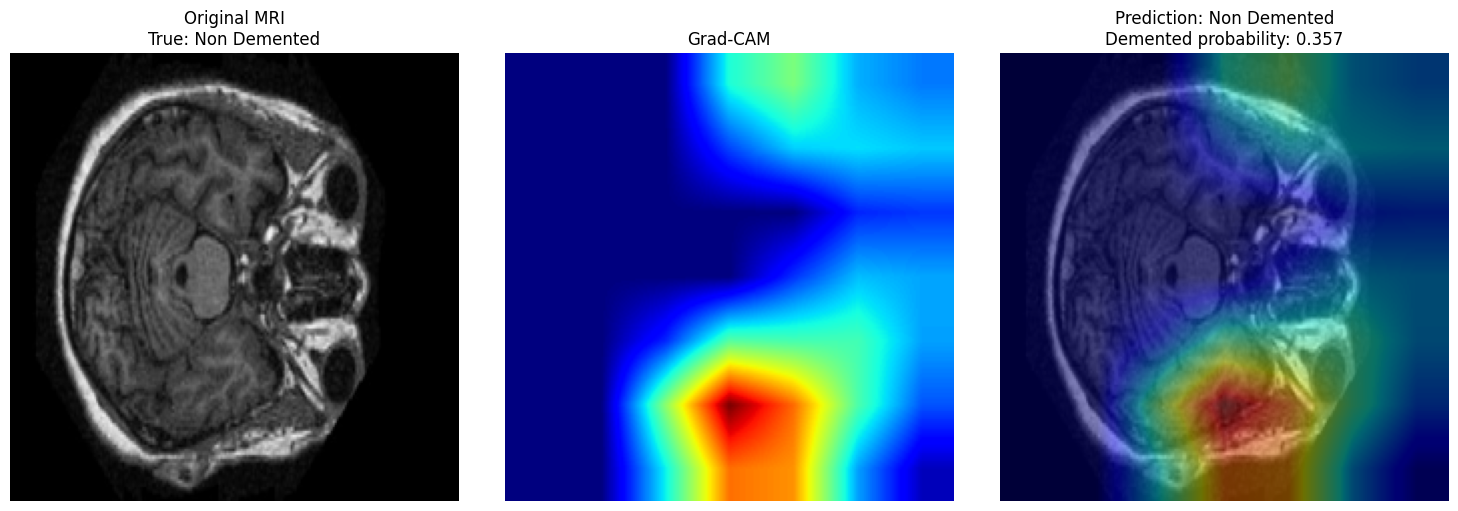

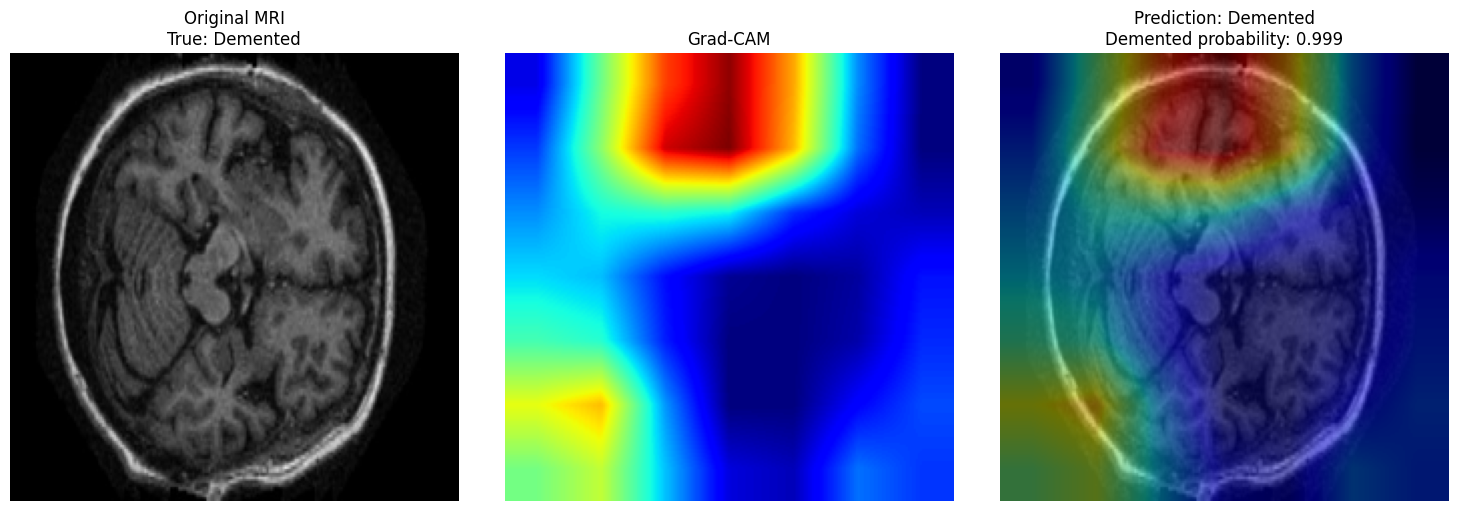

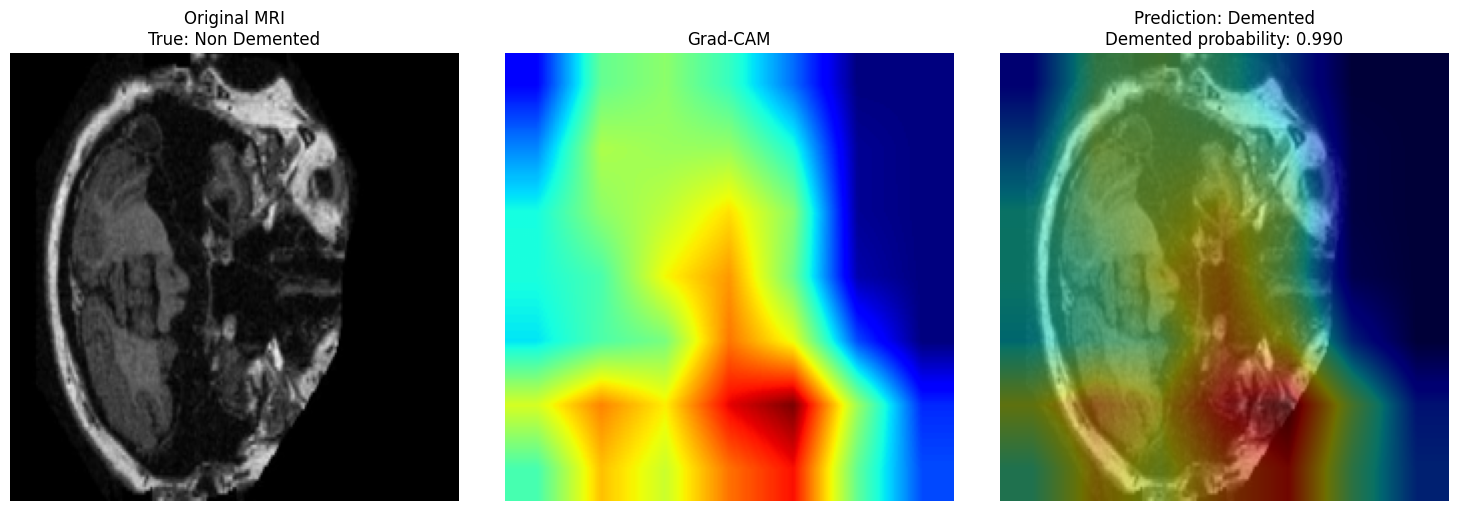

Grad-CAM examples saved to: /kaggle/working/gradcam


In [29]:
def visualize_gradcam(path, save_path=None, target_class=None):
    original = Image.open(path).convert("RGB")
    x = eval_transform(original).unsqueeze(0).to(DEVICE)

    cam, probs, pred = gradcam.generate(x, target_class=target_class)

    display_img = original.resize((IMG_SIZE, IMG_SIZE))
    true_label = binary_label_from_path(path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(display_img)
    axes[0].set_title(
        f"Original MRI\nTrue: {BINARY_CLASS_NAMES[true_label]}"
    )
    axes[0].axis("off")

    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(display_img)
    axes[2].imshow(cam, cmap="jet", alpha=0.45)
    axes[2].set_title(
        f"Prediction: {BINARY_CLASS_NAMES[pred]}\n"
        f"Demented probability: {probs[1]:.3f}"
    )
    axes[2].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    return pred, probs


# BUG FIX: the original cell referenced `test_df` and `GRADCAM_DIR`,
# neither of which exists in this notebook -> NameError.
# The held-out slices live in the `test_paths` list.
rng = random.Random(SEED)

example_paths = rng.sample(
    test_paths,
    min(3, len(test_paths))
)

for i, example_path in enumerate(example_paths, start=1):
    save_path = os.path.join(GRADCAM_DIR, f"gradcam_example_{i}.png")
    visualize_gradcam(example_path, save_path=save_path)

gradcam.close()
print("Grad-CAM examples saved to:", GRADCAM_DIR)

## 18 — Final experiment summary

We print a comprehensive summary of the entire experiment, logging the final subject counts, the architectural decisions, and the ultimate test-set performance metrics.

In [30]:
print("=" * 72)
print("MedScan — Binary ResNet34 Experiment")
print("=" * 72)

print("Task:", "Non Demented vs Demented")
print(
    "Transfer learning:",
    "Head → layer4 → full backbone"
)

print(
    "Train subjects:",
    len(train_subjects)
)

print(
    "Validation subjects:",
    len(val_subjects)
)

print(
    "Test subjects:",
    len(test_subjects)
)

print(
    "Best validation Macro-F1:",
    f"{best_f1:.4f}"
)

print()
print("Slice-level results:")

for key, value in test_metrics.items():

    if np.isfinite(value):
        print(
            f"  {key}: {value:.4f}"
        )

print()
print("Subject-level results:")

for key, value in subject_metrics.items():

    if np.isfinite(value):
        print(
            f"  {key}: {value:.4f}"
        )

print()
print(
    "Deployment checkpoint:",
    BEST_MODEL_PATH
)

print(
    "Grad-CAM target layer:",
    "model.layer4"
)

print("=" * 72)

MedScan — Binary ResNet34 Experiment
Task: Non Demented vs Demented
Transfer learning: Head → layer4 → full backbone
Train subjects: 277
Validation subjects: 35
Test subjects: 35
Best validation Macro-F1: 0.7756

Slice-level results:
  accuracy: 0.7233
  balanced_accuracy: 0.6715
  macro_f1: 0.6468
  roc_auc: 0.7797
  loss: 0.9625

Subject-level results:
  accuracy: 0.8000
  balanced_accuracy: 0.7384
  macro_f1: 0.7281
  roc_auc: 0.8148

Deployment checkpoint: /kaggle/working/checkpoints/best_resnet34_binary_subject_split.pth
Grad-CAM target layer: model.layer4


## Final checkpoint verification

We execute a dry-run reload of the saved checkpoint to prove that the weights and architecture can be successfully restored from disk in a production environment.

In [31]:
# Final checkpoint reload verification
verification_model = build_model()

verification_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

verification_model.load_state_dict(
    verification_checkpoint["model_state_dict"]
)
verification_model.eval()

print("Final checkpoint reload verified.")
print("Architecture:", verification_checkpoint["architecture"])
print("Class names:", verification_checkpoint["class_names"])
print(
    "Best validation macro-F1:",
    round(verification_checkpoint["best_val_macro_f1"], 4)
)
print("Checkpoint path:", BEST_MODEL_PATH)

# Confirm the reloaded weights match the in-memory model exactly.
mismatched = [
    name
    for name, tensor in model.state_dict().items()
    if not torch.equal(
        tensor.cpu(),
        verification_model.state_dict()[name].cpu()
    )
]

if mismatched:
    print("WARNING: mismatched tensors:", mismatched[:5])
else:
    print("Saved weights match the evaluated model exactly.")

Final checkpoint reload verified.
Architecture: resnet34
Class names: ['Non Demented', 'Demented']
Best validation macro-F1: 0.7756
Checkpoint path: /kaggle/working/checkpoints/best_resnet34_binary_subject_split.pth
Saved weights match the evaluated model exactly.


In [32]:
import os
import zipfile
from IPython.display import FileLink, display

# Name of the zip file to create
zip_filename = "medscan_results.zip"
zip_path = os.path.join("/kaggle/working", zip_filename)

print("Creating zip archive...")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # 1. Add the best model checkpoint
    if os.path.exists(BEST_MODEL_PATH):
        zipf.write(BEST_MODEL_PATH, arcname=os.path.basename(BEST_MODEL_PATH))
        print(f"Added checkpoint: {os.path.basename(BEST_MODEL_PATH)}")
    else:
        print("Checkpoint not found!")

    # 2. Add all Grad-CAM images
    if os.path.exists(GRADCAM_DIR):
        for root, dirs, files in os.walk(GRADCAM_DIR):
            for file in files:
                file_path = os.path.join(root, file)
                # Keep them inside a 'gradcam' folder within the zip
                arcname = os.path.join("gradcam", file)
                zipf.write(file_path, arcname=arcname)
        print(f"Added Grad-CAM images from: {GRADCAM_DIR}")
    else:
        print("Grad-CAM directory not found!")

print("\nDone! Click the link below to download:")
display(FileLink(zip_filename))

Creating zip archive...
Added checkpoint: best_resnet34_binary_subject_split.pth
Added Grad-CAM images from: /kaggle/working/gradcam

Done! Click the link below to download:


/kaggle/working/medscan_results.zip